In [1]:
!pip install pydicom pillow pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from pathlib import Path

INPUT_DIR = Path("/content/drive/MyDrive/dicom/DICOM_2600053671_VTKL_58143")
OUTPUT_DIR = Path("/content/drive/MyDrive/dicom/dicom_output_png")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input:", INPUT_DIR)
print("Output:", OUTPUT_DIR)

Input: /content/drive/MyDrive/dicom/DICOM_2600053671_VTKL_58143
Output: /content/drive/MyDrive/dicom/dicom_output_png


In [7]:
import pydicom
import numpy as np
from PIL import Image

def dicom_to_uint8(ds):
    img = ds.pixel_array.astype(np.float32)

    # Áp dụng Rescale Slope / Intercept nếu có
    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    img = img * slope + intercept

    # Xử lý ảnh MONOCHROME1 nếu bị ngược sáng
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = np.max(img) - img

    # Chuẩn hóa về 0-255
    img = img - np.min(img)

    if np.max(img) > 0:
        img = img / np.max(img)

    img = (img * 255).astype(np.uint8)

    return img

In [8]:
import os

count = 0
error_files = []

for file_path in INPUT_DIR.rglob("*"):
    if file_path.is_file() and file_path.name != ".DS_Store":
        try:
            ds = pydicom.dcmread(str(file_path), force=True)

            # Bỏ qua file không có ảnh
            if not hasattr(ds, "PixelData"):
                continue

            img = dicom_to_uint8(ds)

            relative_path = file_path.relative_to(INPUT_DIR)
            output_subdir = OUTPUT_DIR / relative_path.parent
            output_subdir.mkdir(parents=True, exist_ok=True)

            output_path = output_subdir / f"{file_path.stem}.png"

            Image.fromarray(img).save(output_path)

            count += 1
            print("Saved:", output_path)

        except Exception as e:
            error_files.append((str(file_path), str(e)))

print("Hoàn thành.")
print("Số ảnh đã chuyển:", count)
print("Số file lỗi:", len(error_files))

Saved: /content/drive/MyDrive/dicom/dicom_output_png/0000/1.3.10001.14.52730922926470730268606127335682754332.png
Saved: /content/drive/MyDrive/dicom/dicom_output_png/0001/1.3.10001.14.95758957378087096715984795550821564080.png
Hoàn thành.
Số ảnh đã chuyển: 2
Số file lỗi: 0


Tổng số ảnh PNG: 2


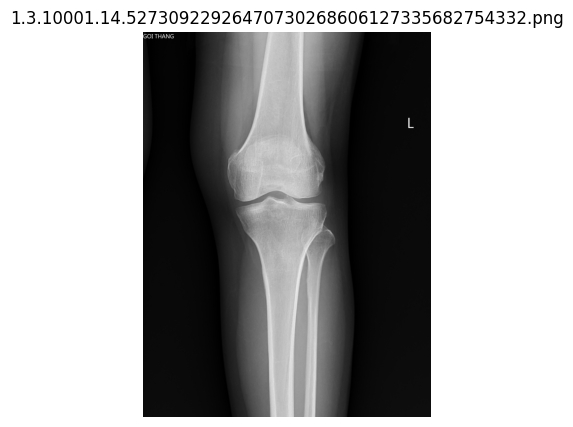

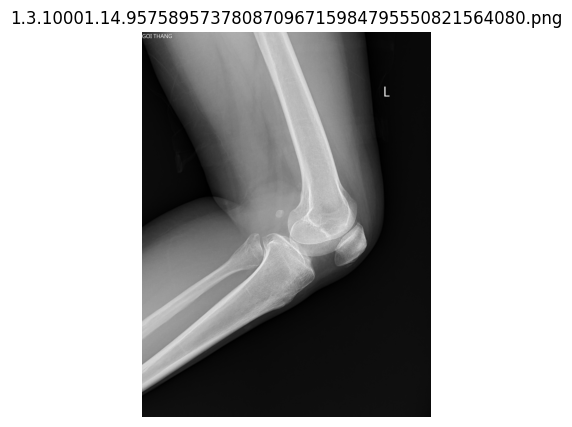

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

png_files = list(OUTPUT_DIR.rglob("*.png"))

print("Tổng số ảnh PNG:", len(png_files))

for img_path in png_files[:5]:
    img = Image.open(img_path)

    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap="gray")
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

In [10]:
import shutil

zip_path = "/content/dicom_output_png.zip"

shutil.make_archive(
    base_name="/content/dicom_output_png",
    format="zip",
    root_dir=str(OUTPUT_DIR)
)

print("Đã tạo file zip:", zip_path)

Đã tạo file zip: /content/dicom_output_png.zip


In [11]:
from google.colab import files
files.download("/content/dicom_output_png.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>